## Voting Classifier

In [1]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv("E:/Machine Learning/Dataset/Iris.csv")


In [8]:
df.head()

,Unnamed: 0,sepalLength,sepalWidth,petalLength,petalWidth,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa


In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
# Label encode Species
from sklearn.preprocessing import LabelEncoder

In [12]:
encoder = LabelEncoder()

In [13]:
df["species"] = encoder.fit_transform(df["species"])

In [14]:
df.head()

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


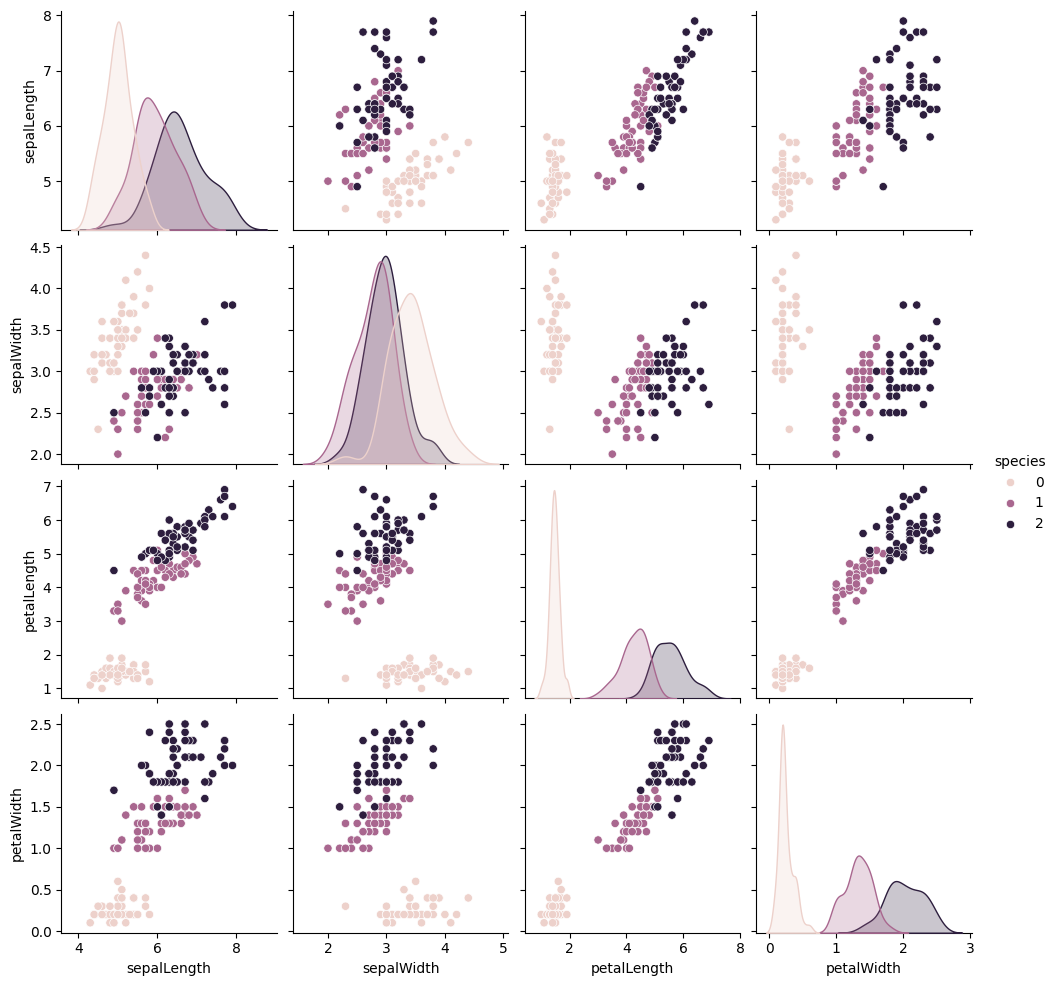

In [17]:
import seaborn as sns
# correct function name and actual column name
sns.pairplot(df, hue='species')

In [20]:
new_df = df[df['species']!=0][["sepalLength","sepalWidth","species"]]

In [21]:
new_df.head()

,sepalLength,sepalWidth,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [22]:
new_df.shape

(100, 3)

In [23]:
X = df.iloc[:,0:2]
y = df.iloc[:, -1]

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [25]:
clf1 = LogisticRegression()
clf2 =RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [26]:
estimators = [('lr', clf1), ('rf', clf2), ('knn', clf3)]

In [28]:
for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, scoring= "accuracy", cv= 5)
    print(estimator[0], np.round(np.mean(x),2))

lr 0.81
rf 0.75
knn 0.76


In [29]:
from sklearn.ensemble import VotingClassifier

## Hard Voting

In [31]:
vc = VotingClassifier(estimators = estimators, voting = "hard")
x = cross_val_score(vc, X,y, scoring= "accuracy")
print(np.round(np.mean(x),2))

0.79


## Soft Voting

In [33]:
vc = VotingClassifier(estimators= estimators, voting= "soft")
x = cross_val_score(vc, X,y, scoring= "accuracy",cv = 5)
print(np.round(np.mean(x),2))

0.78


## Weighted Voting

In [34]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting= "soft",weights = [i,j,k])
            x = cross_val_score(vc, X, y, scoring = "accuracy")
            print("for i = {}, j = {}, k = {}".format(i,j,k),np.round(np.mean(x),2))

for i = 1, j = 1, k = 1 0.78
for i = 1, j = 1, k = 2 0.77
for i = 1, j = 1, k = 3 0.77
for i = 1, j = 2, k = 1 0.78
for i = 1, j = 2, k = 2 0.78
for i = 1, j = 2, k = 3 0.77
for i = 1, j = 3, k = 1 0.77
for i = 1, j = 3, k = 2 0.77
for i = 1, j = 3, k = 3 0.77
for i = 2, j = 1, k = 1 0.79
for i = 2, j = 1, k = 2 0.79
for i = 2, j = 1, k = 3 0.79
for i = 2, j = 2, k = 1 0.78
for i = 2, j = 2, k = 2 0.79
for i = 2, j = 2, k = 3 0.77
for i = 2, j = 3, k = 1 0.78
for i = 2, j = 3, k = 2 0.77
for i = 2, j = 3, k = 3 0.77
for i = 3, j = 1, k = 1 0.79
for i = 3, j = 1, k = 2 0.79
for i = 3, j = 1, k = 3 0.79
for i = 3, j = 2, k = 1 0.79
for i = 3, j = 2, k = 2 0.79
for i = 3, j = 2, k = 3 0.79
for i = 3, j = 3, k = 1 0.78
for i = 3, j = 3, k = 2 0.78
for i = 3, j = 3, k = 3 0.78


## Classifiers of Same Algo

In [36]:
from sklearn.svm import SVC

In [37]:
from sklearn.datasets import make_classification 

In [38]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=23)

svm1 = SVC(probability=True, kernel='poly', degree =1)
svm2 = SVC(probability=True, kernel='poly', degree =2)
svm3 = SVC(probability=True, kernel='poly', degree =3)
svm4 = SVC(probability=True, kernel='poly', degree =4)
svm5 = SVC(probability=True, kernel='poly', degree =5)

estimators = [('svm1', svm1), ('svm2', svm2), ('svm3', svm3), ('svm4', svm4), ('svm5', svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, cv=10, scoring="accuracy")
    print(estimator[0], np.round(np.mean(x),2))

svm1 0.85
svm2 0.89
svm3 0.88
svm4 0.84
svm5 0.81


In [41]:

vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.92
